In [71]:
# Use SQLAlchemy to collect chemical data from an old DSSTOX
import sqlalchemy
from sqlalchemy import create_engine
from sqlalchemy.ext.automap import automap_base
from sqlalchemy.orm import Session

In [73]:
from config import username, passwordword
username = "username"
passwordword = "password"
database_path = "ccte-mysql-res.epa.gov"
engine = create_engine(f"mysql+mysqlconnector://{username}:{passwordword}@{database_path}/prod_dsstox")
conn = engine.connect()

In [74]:
Base = automap_base()
Base.prepare(autoload_with=engine)

In [75]:
chems = Base.metadata.tables['dsstox_names']

In [76]:
session = Session(engine)

In [77]:
import pandas as pd
first_df = pd.read_sql_query("SELECT dtxsid FROM dsstox_names ORDER BY RAND() LIMIT 2000 ", engine)


In [78]:
second_df = pd.read_sql_query("SELECT dtxsid FROM dsstox_names ORDER BY RAND() LIMIT 2000 ", engine)

In [79]:
session.rollback()
session.close()

In [80]:
fingerprint_df = pd.concat([first_df, second_df], axis = 0)

In [81]:
fingerprint_df.to_csv('../src/data/fingerprint_analysis.csv')

In [3]:
import pandas as pd
fingerprint_df = pd.read_csv(f"../src/data/print_analysis_2_pre-grid-search.csv")

In [5]:
from sklearn.metrics import pairwise_distances
import numpy as np

end = int(len(fingerprint_df)/2)

slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, 5727), slice(5727, None)]

tp_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[0]]), np.array(fingerprint_df.iloc[end:,slices[0]]), metric = 'jaccard')
mor_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[1]]), np.array(fingerprint_df.iloc[end:,slices[1]]), metric = 'jaccard')
tor_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[2]]), np.array(fingerprint_df.iloc[end:,slices[2]]), metric = 'jaccard')
aims_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[3]]), np.array(fingerprint_df.iloc[end:,slices[3]]), metric = 'jaccard')
test_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[4]]), np.array(fingerprint_df.iloc[end:,slices[4]]), metric = 'jaccard')

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [6]:
def metricList(metric_matrix):
    diagonal_list = []
    for i in range(658):
        for j in range(658):
            if i == j:
                diagonal_list.append(metric_matrix[i,j])
    return diagonal_list

tp_dist = metricList(tp_dist_matrix)
mor_dist = metricList(mor_dist_matrix)
tor_dist = metricList(tor_dist_matrix)
aims_dist = metricList(aims_dist_matrix)
test_dist = metricList(test_dist_matrix)


0.3043430974973832


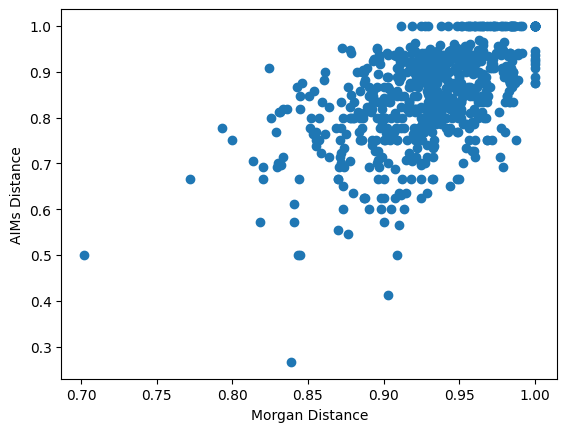

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

def printPlots(print1, print2, print1_name, print2_name):
    plt.scatter(print1, print2)
    m,b = np.polyfit(print1, print2, deg = 1)
    print(r2_score(print2, m*np.array(print1)+b))
    plt.xlabel(f'{print1_name} Distance')
    plt.ylabel(f'{print2_name} Distance')
    plt.show()
    return

printPlots(mor_dist, aims_dist, 'Morgan', 'AIMs' )

0.30395067031321354


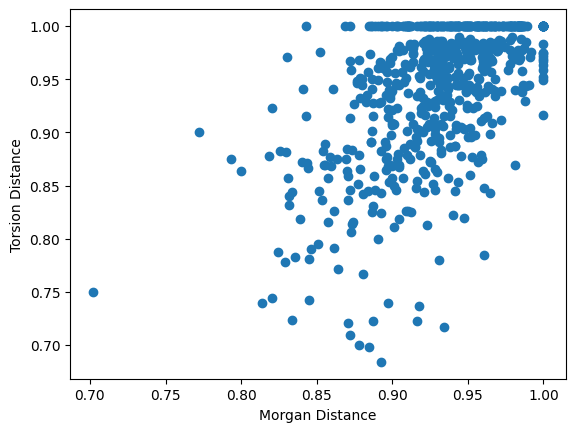

In [8]:
printPlots(mor_dist, tor_dist, "Morgan", "Torsion")

0.2360507263639101


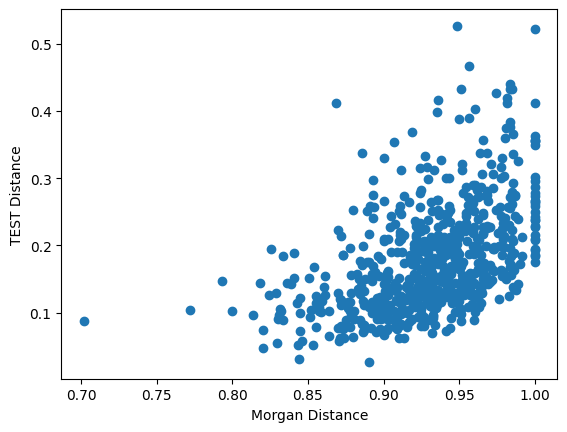

In [9]:
printPlots(mor_dist, test_dist, 'Morgan', 'TEST')

0.36325468751780055


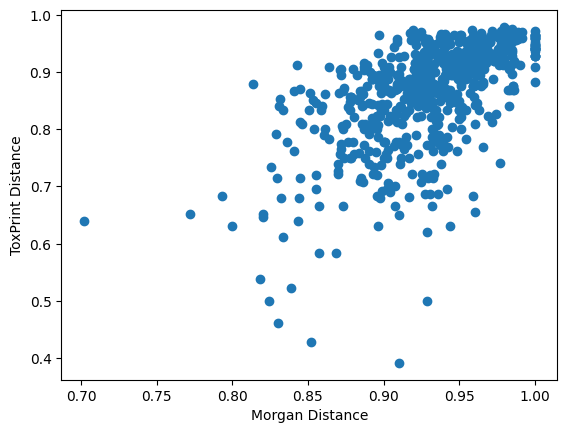

In [10]:
printPlots(mor_dist, tp_dist, 'Morgan', 'ToxPrint')

0.0663978390865142


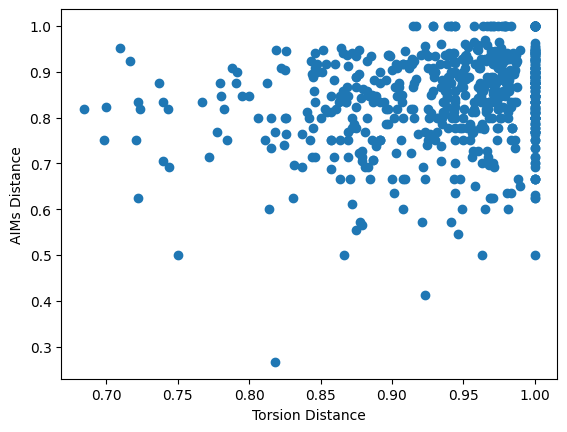

In [11]:
printPlots(tor_dist, aims_dist, "Torsion", 'AIMs')

0.14401540495794385


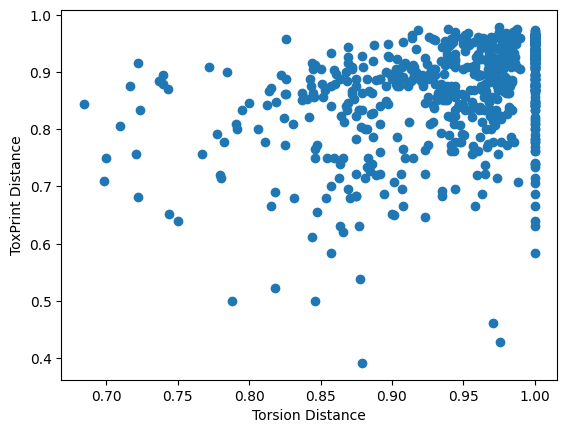

In [12]:
printPlots(tor_dist, tp_dist, "Torsion", 'ToxPrint')

0.19131129564856308


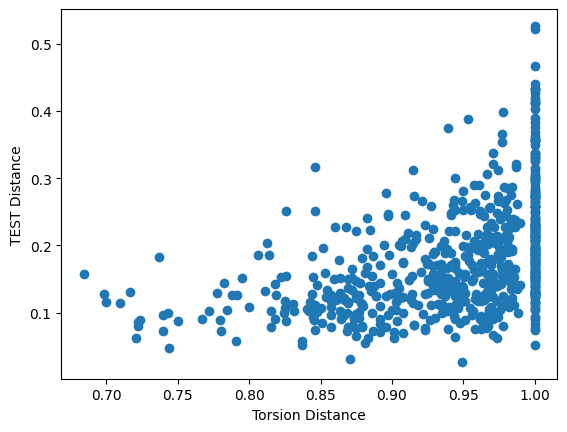

In [13]:
printPlots(tor_dist, test_dist, "Torsion", 'TEST')

0.22369292138800279


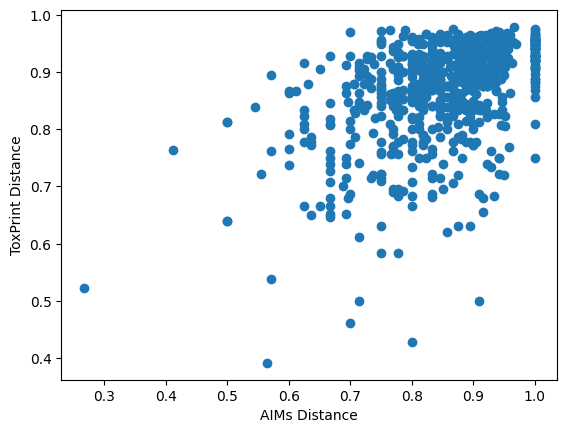

In [14]:
printPlots(aims_dist, tp_dist, "AIMs", 'ToxPrint')

0.16677994245625316


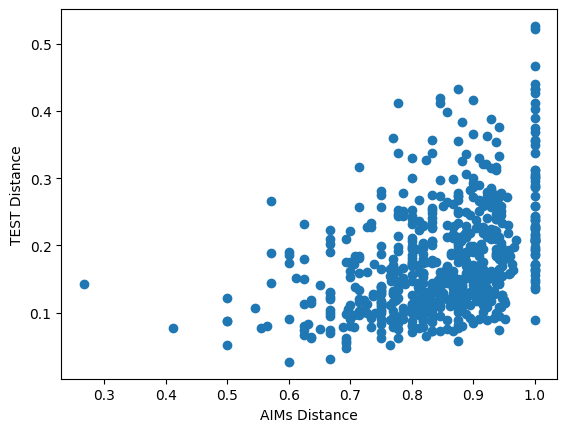

In [15]:
printPlots(aims_dist, test_dist, "AIMs", 'TEST')

0.12224758320175289


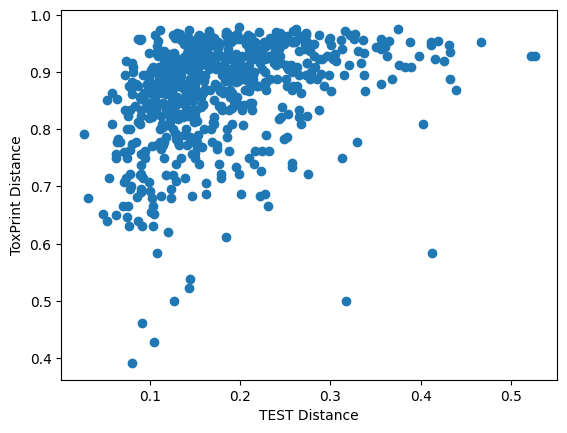

In [16]:
printPlots(test_dist, tp_dist, "TEST", 'ToxPrint')